In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
attack_df = pd.read_csv("CTU13_Attack_Traffic.csv")
normal_df = pd.read_csv("CTU13_Normal_Traffic.csv")

print("Attack shape:", attack_df.shape)
print("Normal shape:", normal_df.shape)

attack_df["Label"] = 1 
normal_df["Label"] = 0  

df = pd.concat([attack_df, normal_df], ignore_index=True)

print("Total shape:", df.shape)
df.head()


Attack shape: (38898, 59)
Normal shape: (53314, 59)
Total shape: (92212, 59)


,Unnamed: 0,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Act Data Pkts,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,59086131,7,1,0,0,0,0,0.000000,0.000000,...,0,2987276.0,0.0,2987276,2987276,1.869962e+07,19471121.45,41116855,5999291,1
1,1,12452268,37,1,2408,68,68,50,65.081081,6.726310,...,37,0.0,0.0,0,0,0.000000e+00,0.00,0,0,1
2,2,118741070,5,4,170,682,45,22,34.000000,10.440307,...,5,2276383.0,0.0,2276383,2276383,1.161281e+08,0.00,116128125,116128125,1
3,3,180643,25,11,180,25790,90,0,7.200000,24.919872,...,2,0.0,0.0,0,0,0.000000e+00,0.00,0,0,1
4,4,440,4,1,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,0.000000e+00,0.00,0,0,1


In [3]:
df.info()

df.describe().T.head(20)

print(df["Label"].value_counts())
print(df["Label"].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92212 entries, 0 to 92211
Data columns (total 59 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         92212 non-null  int64  
 1   Flow Duration      92212 non-null  int64  
 2   Tot Fwd Pkts       92212 non-null  int64  
 3   Tot Bwd Pkts       92212 non-null  int64  
 4   TotLen Fwd Pkts    92212 non-null  int64  
 5   TotLen Bwd Pkts    92212 non-null  int64  
 6   Fwd Pkt Len Max    92212 non-null  int64  
 7   Fwd Pkt Len Min    92212 non-null  int64  
 8   Fwd Pkt Len Mean   92212 non-null  float64
 9   Fwd Pkt Len Std    92212 non-null  float64
 10  Bwd Pkt Len Max    92212 non-null  int64  
 11  Bwd Pkt Len Min    92212 non-null  int64  
 12  Bwd Pkt Len Mean   92212 non-null  float64
 13  Bwd Pkt Len Std    92212 non-null  float64
 14  Flow Byts/s        92212 non-null  float64
 15  Flow Pkts/s        92212 non-null  float64
 16  Flow IAT Mean      922

In [4]:
cols_to_drop = [
    "Flow ID", "Src IP", "Dst IP", "Timestamp",
    "Src Port", "Dst Port"
]

df = df.drop(columns=cols_to_drop, errors="ignore")
df.head()


,Unnamed: 0,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Act Data Pkts,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,59086131,7,1,0,0,0,0,0.000000,0.000000,...,0,2987276.0,0.0,2987276,2987276,1.869962e+07,19471121.45,41116855,5999291,1
1,1,12452268,37,1,2408,68,68,50,65.081081,6.726310,...,37,0.0,0.0,0,0,0.000000e+00,0.00,0,0,1
2,2,118741070,5,4,170,682,45,22,34.000000,10.440307,...,5,2276383.0,0.0,2276383,2276383,1.161281e+08,0.00,116128125,116128125,1
3,3,180643,25,11,180,25790,90,0,7.200000,24.919872,...,2,0.0,0.0,0,0,0.000000e+00,0.00,0,0,1
4,4,440,4,1,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,0.000000e+00,0.00,0,0,1


In [5]:
y = df["Label"]

X = df.drop(columns=["Label"])

X = pd.get_dummies(X)

print("Final features shape:", X.shape)


Final features shape: (92212, 58)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 73769
Test size: 18443


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = clf.predict(X_test_scaled)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

Confusion matrix:
[[10645    18]
 [   14  7766]]

Classification report:
              precision    recall  f1-score   support

           0     0.9987    0.9983    0.9985     10663
           1     0.9977    0.9982    0.9979      7780

    accuracy                         0.9983     18443
   macro avg     0.9982    0.9983    0.9982     18443
weighted avg     0.9983    0.9983    0.9983     18443



In [2]:
!pip install --user umap-learn


   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]



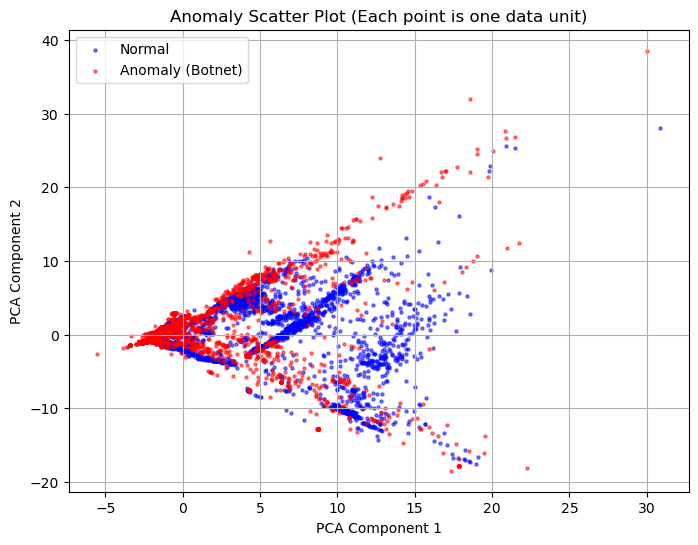

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)

normal_points = X_pca[y_test.values == 0]
anomaly_points = X_pca[y_test.values == 1]

plt.figure(figsize=(8, 6))
plt.scatter(normal_points[:, 0], normal_points[:, 1], 
            s=5, c='blue', alpha=0.5, label='Normal')

plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1], 
            s=5, c='red', alpha=0.5, label='Anomaly (Botnet)')

plt.title("Anomaly Scatter Plot (Each point is one data unit)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import umap
import warnings
warnings.filterwarnings("ignore")
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    verbose=False
)

X_umap = reducer.fit_transform(X_test_scaled)

normal_points = X_umap[y_test.values == 0]
anomaly_points = X_umap[y_test.values == 1]

plt.figure(figsize=(10, 7))
plt.scatter(normal_points[:, 0], normal_points[:, 1],
            s=6, c='blue', alpha=0.4, label='Normal')

plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1],
            s=6, c='red', alpha=0.6, label='Anomaly (Botnet)')

plt.title("UMAP Anomaly Visualization (Each point = flow unit)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True)
plt.legend()
plt.show()

SyntaxError: invalid syntax (3875182496.py, line 1)